## import Library


In [ ]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

## Load Preprocessed Dataset

In [ ]:
dataset = pd.read_csv('/content/(Preprocessed)Emotion_classify_Data(Labeled).csv')

In [ ]:
# Shuffle the dataset
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5934 entries, 0 to 5933
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Comment  5934 non-null   object
 1   Emotion  5934 non-null   object
dtypes: object(2)
memory usage: 92.8+ KB


## Dive into BERT

In [ ]:
# Initialize BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize text
tokenized = dataset['Comment'].apply((lambda x: tokenizer.encode_plus(x, add_special_tokens=True, max_length=128, padding='max_length', truncation=True)))

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# Extract input_ids and attention_masks
input_ids = [tokenized[i]['input_ids'] for i in range(len(tokenized))]
attention_masks = [tokenized[i]['attention_mask'] for i in range(len(tokenized))]

In [ ]:
# Encode emotion labels
emotion_labels = dataset['Emotion'].astype('category').cat.codes.values.astype('long')
emotion_labels

array([2, 0, 0, ..., 2, 1, 1])

In [ ]:
# First, split the data into training+validation and test sets
train_val_inputs, test_inputs, train_val_masks, test_masks, train_val_labels, test_labels = train_test_split(
    input_ids, attention_masks, emotion_labels, random_state=42, test_size=0.2
)

# Then, split the training+validation set into separate training and validation sets
train_inputs, val_inputs, train_masks, val_masks, train_labels, val_labels = train_test_split(
    train_val_inputs, train_val_masks, train_val_labels, random_state=42, test_size=0.25
)

In [ ]:
# Convert lists to tensors
train_inputs = torch.tensor(train_inputs)
val_inputs = torch.tensor(val_inputs)
train_masks = torch.tensor(train_masks)
val_masks = torch.tensor(val_masks)
train_labels = torch.tensor(train_labels)
val_labels = torch.tensor(val_labels)
test_inputs = torch.tensor(test_inputs)
test_masks = torch.tensor(test_masks)
test_labels = torch.tensor(test_labels)

In [ ]:
# Define batch size
batch_size = 32

# Create TensorDatasets
train_data = TensorDataset(train_inputs, train_masks, train_labels)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

val_data = TensorDataset(val_inputs, val_masks, val_labels)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

test_data = TensorDataset(test_inputs, test_masks, test_labels)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [ ]:
# Load pre-trained BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=dataset['Emotion'].nunique())

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Fine-tune BERT on your dataset
learning_rate = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
import torch.nn.functional as F

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# Initialize lists to track loss and accuracy
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Move optimizer to the same device as the model
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Initialize variables to track early stopping
best_val_loss = float('inf')
early_stop_count = 0
patience = 3  # Number of epochs to wait before early stopping if no improvement

for epoch in range(50):  # Train for 50 epochs
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/50'):  # Use tqdm for progress bar
        optimizer.zero_grad()
        # Move batch to GPU
        batch = tuple(t.to(device) for t in batch)
        input_ids, attention_mask, labels = batch

        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Cast logits to Float data type
        logits = logits.float()

        # Calculate loss (ensure labels are Long data type)
        loss = F.cross_entropy(logits, labels.long())
        total_loss += loss.item()

        # Calculate accuracy
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_dataloader)
    train_losses.append(avg_loss)
    train_accuracy = accuracy_score(all_labels, all_preds)
    train_accuracies.append(train_accuracy)
    print(f'Epoch {epoch+1}/50, Avg. Loss: {avg_loss}, Train Accuracy: {train_accuracy}')

    # Validate the model after each epoch
    model.eval()
    val_loss = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
             # Move batch to GPU if available
            batch = tuple(t.to(device) for t in batch)
            input_ids, attention_mask, labels = batch

            # Call model.forward on the same device as the inputs
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # Cast logits to Float data type
            logits = logits.float()

            # Calculate validation loss
            loss = F.cross_entropy(logits, labels.long())
            val_loss += loss.item()

            # Calculate accuracy
            preds = torch.argmax(logits, dim=1)
            all_val_preds.extend(preds.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    val_accuracy = accuracy_score(all_val_labels, all_val_preds)
    val_accuracies.append(val_accuracy)
    print(f'Epoch {epoch+1}/50, Avg. Validation Loss: {avg_val_loss}, Validation Accuracy: {val_accuracy}')

    # Check for early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_count = 0
    else:
        early_stop_count += 1
        if early_stop_count >= patience:
            print(f'Validation loss has not improved for {patience} epochs. Early stopping...')
            break




Epoch 1/50: 100%|██████████| 112/112 [01:08<00:00,  1.64it/s]


Epoch 1/50, Avg. Loss: 0.7133128521963954, Train Accuracy: 0.6716292134831461
Epoch 1/50, Avg. Validation Loss: 0.2514359219685981, Validation Accuracy: 0.9123841617523167


Epoch 2/50: 100%|██████████| 112/112 [01:07<00:00,  1.66it/s]


Epoch 2/50, Avg. Loss: 0.15232663912632102, Train Accuracy: 0.952808988764045
Epoch 2/50, Avg. Validation Loss: 0.15468391484433883, Validation Accuracy: 0.9486099410278012


Epoch 3/50: 100%|██████████| 112/112 [01:07<00:00,  1.66it/s]


...

Epoch 4/50, Avg. Loss: 0.030819230463488827, Train Accuracy: 0.9907303370786517
Epoch 4/50, Avg. Validation Loss: 0.1433504554565604, Validation Accuracy: 0.9502948609941028


Epoch 5/50: 100%|██████████| 112/112 [01:07<00:00,  1.66it/s]


Epoch 5/50, Avg. Loss: 0.03288639176337581, Train Accuracy: 0.9890449438202247
Epoch 5/50, Avg. Validation Loss: 0.15705603908894486, Validation Accuracy: 0.9519797809604044


Epoch 6/50: 100%|██████████| 112/112 [01:07<00:00,  1.66it/s]


Epoch 6/50, Avg. Loss: 0.01909474371184063, Train Accuracy: 0.9938202247191011
Epoch 6/50, Avg. Validation Loss: 0.16489387515589202, Validation Accuracy: 0.9604043807919124
Validation loss has not improved for 3 epochs. Early stopping...


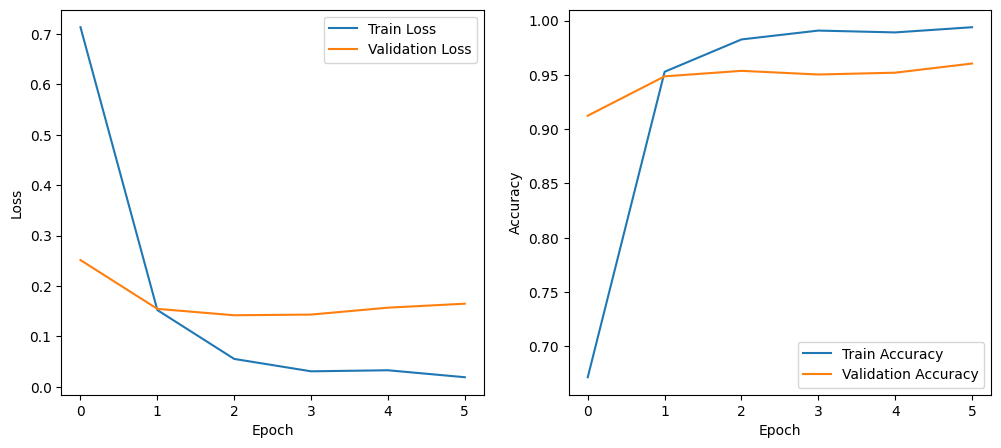

In [ ]:
# Plot the training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
model.eval()
total_accurate = 0
test_loss = 0

all_predicted_labels = []
all_true_labels = []

for batch in test_dataloader:
     # Move batch to GPU if available
    batch = tuple(t.to(device) for t in batch)
    input_ids, attention_mask, labels = batch

    # Call prediction
    outputs = model(input_ids.to(device), attention_mask=attention_mask.to(device))
    logits = outputs.logits

    # Cast logits to Long data type
    logits = logits.float()

    # Calculate loss (ensure labels are Long data type)
    loss = F.cross_entropy(logits, labels.long())
    test_loss += loss.item()

    # Calculate performance
    _, predicted_labels = torch.max(logits, dim=1)
    correct_predictions = torch.sum(predicted_labels == labels)
    total_accurate += correct_predictions.item()

    # Append predicted and true labels for confusion matrix calculation
    all_predicted_labels.extend(predicted_labels.cpu().numpy())
    all_true_labels.extend(labels.cpu().numpy())

avg_val_loss = val_loss / len(val_dataloader)
avg_accuracy = total_accurate / len(val_data)
print(f'Validation Loss: {avg_val_loss}, Test Accuracy: {avg_accuracy}')

# Calculate confusion matrix
conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

Validation Loss: 0.16489387515589202, Test Accuracy: 0.9561920808761584
Confusion Matrix:
[[375  23   4]
 [  2 392   1]
 [  7  15 368]]


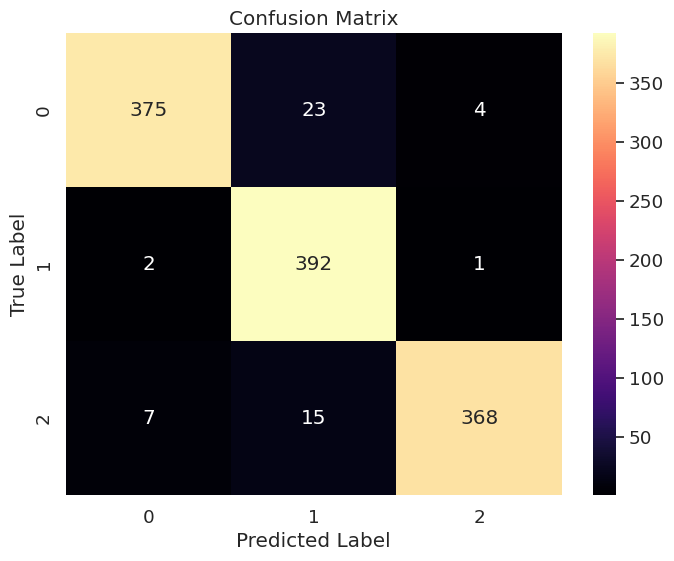

In [ ]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(conf_matrix, annot=True, cmap='magma', fmt='g', xticklabels=True, yticklabels=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Compute precision, recall, and F1 score
precision = precision_score(all_true_labels, all_predicted_labels, average='weighted')
recall = recall_score(all_true_labels, all_predicted_labels, average='weighted')
f1 = f1_score(all_true_labels, all_predicted_labels, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {avg_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Accuracy: 0.9561920808761584
Precision: 0.9582504348932437
Recall: 0.9561920808761584
F1 Score: 0.956324091709895


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Assuming 'emotion_labels' contains the encoded emotion labels
# emotion_labels = dataset['Emotion'].astype('category').cat.codes.values.astype('long')
emotion_labels = dataset['Emotion']

# Instantiate the label encoder
label_encoder = LabelEncoder()

# Fit the label encoder to the encoded emotion labels
label_encoder.fit(emotion_labels)


LabelEncoder()

In [ ]:
def predict_emotion(text, label_encoder):
    # Tokenize the text using the same tokenizer used during training
    inputs = tokenizer.encode_plus(text, add_special_tokens=True, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)  # Move input to the same device as the model
    attention_mask = inputs['attention_mask'].to(device)  # Move attention mask to the same device as the model

    # Make prediction
    with torch.no_grad():
        model.eval()  # Set model to evaluation mode
        outputs = model(input_ids, attention_mask=attention_mask)
    logits = outputs.logits

    # Get predicted label
    predicted_label = torch.argmax(logits, dim=1).item()

    # Decode the predicted label using label_encoder
    predicted_emotion = label_encoder.inverse_transform([predicted_label])[0]

    return predicted_emotion, logits

# Example usage
text = "I'm happy"
predicted_emotion, predicted_label = predict_emotion(text, label_encoder)
print(f'Predicted Emotion: {predicted_emotion}')
print(f'Predicted Label: {predicted_label}')


Predicted Emotion: joy
Predicted Label: tensor([[-1.8068, -2.3460,  5.4301]], device='cuda:0')


In [ ]:
# Save the last trained model
checkpoint = {
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'early_stop_count': early_stop_count
}

torch.save(checkpoint, 'last_trained_model_checkpoint_2.0.pth')
